# Edu Growth - Data Cleaning + EDA (99 Columns)
Missing values (0 se fill), galat values, outliers - sab 99 columns mein. Mean / median / mode kahin nahi lagaya.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# keep_default_na=False: taaki "N/A" aur "None" strings waise hi rahein, sirf khaali cell missing maani jaye
df = pd.read_csv(
    "messy_edu_growth_99_columns - messy_edu_growth_99_columns.csv.csv",
    keep_default_na=False,
    na_values=[""]
)

In [3]:
df.shape

(49000, 99)

In [4]:
df.head()

        roll_no  ... lab_cyber_submission_delay_hours
0  210029053348  ...                             31.2
1  210029035828  ...                              NaN
2  210029039616  ...                              8.5
3  210029036528  ...                              5.7
4  210029010644  ...                             25.0

[5 rows x 99 columns]

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49000 entries, 0 to 48999
Data columns (total 99 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   roll_no                            49000 non-null  int64  
 1   full_name                          46573 non-null  str    
 2   class_section                      46633 non-null  str    
 3   overall_attendance_pct             46547 non-null  str    
 4   theory_attendance_pct              46529 non-null  float64
 5   practical_attendance_pct           46586 non-null  float64
 6   previous_cgpa                      46541 non-null  float64
 7   medical_leave_days                 46451 non-null  float64
 8   society_participation_pc           46626 non-null  float64
 9   sports_activity_level              46640 non-null  str    
 10  final_semester_grade               46702 non-null  float64
 11  coa_attendance_pct                 46508 non-null  float64
 12  m

In [6]:
df.describe()

            roll_no  ...  lab_cyber_submission_delay_hours
count  4.900000e+04  ...                      46576.000000
mean   2.100290e+11  ...                         20.248366
std    1.341106e+04  ...                         11.467984
min    2.100290e+11  ...                          0.100000
25%    2.100290e+11  ...                         12.100000
50%    2.100290e+11  ...                         18.100000
75%    2.100290e+11  ...                         25.900000
max    2.100291e+11  ...                        120.000000

[8 rows x 95 columns]

In [7]:
df.select_dtypes(include="object").nunique()

full_name                  450
class_section                9
overall_attendance_pct    1669
sports_activity_level        8
dtype: int64

In [8]:
df.dtypes.value_counts()

float64    94
str         4
int64       1
Name: count, dtype: int64

## Duplicates

In [9]:
df.duplicated().sum()

np.int64(2500)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(46500, 99)

## 99 columns ko groups mein baantna

In [13]:
id_cols = ["roll_no"]

text_cols = ["full_name", "class_section", "sports_activity_level"]

attendance_cols = [
    "overall_attendance_pct",
    "theory_attendance_pct",
    "practical_attendance_pct",
    "coa_attendance_pct",
    "maths4_attendance_pct",
    "dstl_attendance_pct",
    "ds_attendance_pct",
    "python_attendance_pct",
    "cyber_attendance_pct",
    "lab_ds_attendance_pct",
    "lab_python_attendance_pct",
    "lab_coa_attendance_pct",
    "lab_cyber_attendance_pct"
]

basic_cols = ["previous_cgpa", "medical_leave_days", "society_participation_pc"]

grade_col = ["final_semester_grade"]

In [14]:
coa_cols = [
    "coa_st1_marks",
    "coa_st2_marks",
    "coa_put_marks",
    "coa_unit_1_marks",
    "coa_unit_2_marks",
    "coa_unit_3_marks",
    "coa_unit_4_marks",
    "coa_unit_5_marks",
    "coa_assignment_score",
    "coa_assignment_delay_hours",
    "coa_quiz_score"
]

maths4_cols = [
    "maths4_st1_marks",
    "maths4_st2_marks",
    "maths4_put_marks",
    "maths4_unit_1_marks",
    "maths4_unit_2_marks",
    "maths4_unit_3_marks",
    "maths4_unit_4_marks",
    "maths4_unit_5_marks",
    "maths4_assignment_score",
    "maths4_assignment_delay_hours",
    "maths4_quiz_score"
]

dstl_cols = [
    "dstl_st1_marks",
    "dstl_st2_marks",
    "dstl_put_marks",
    "dstl_unit_1_marks",
    "dstl_unit_2_marks",
    "dstl_unit_3_marks",
    "dstl_unit_4_marks",
    "dstl_unit_5_marks",
    "dstl_assignment_score",
    "dstl_assignment_delay_hours",
    "dstl_quiz_score"
]

ds_cols = [
    "ds_st1_marks",
    "ds_st2_marks",
    "ds_put_marks",
    "ds_unit_1_marks",
    "ds_unit_2_marks",
    "ds_unit_3_marks",
    "ds_unit_4_marks",
    "ds_unit_5_marks",
    "ds_assignment_score",
    "ds_assignment_delay_hours",
    "ds_quiz_score"
]

python_cols = [
    "python_st1_marks",
    "python_st2_marks",
    "python_put_marks",
    "python_unit_1_marks",
    "python_unit_2_marks",
    "python_unit_3_marks",
    "python_unit_4_marks",
    "python_unit_5_marks",
    "python_assignment_score",
    "python_assignment_delay_hours",
    "python_quiz_score"
]

cyber_cols = [
    "cyber_st1_marks",
    "cyber_st2_marks",
    "cyber_put_marks",
    "cyber_unit_1_marks",
    "cyber_unit_2_marks",
    "cyber_unit_3_marks",
    "cyber_unit_4_marks",
    "cyber_unit_5_marks",
    "cyber_assignment_score",
    "cyber_assignment_delay_hours",
    "cyber_quiz_score"
]

In [15]:
lab_ds_cols = [
    "lab_ds_execution_score",
    "lab_ds_viva_score",
    "lab_ds_submission_delay_hours"
]

lab_python_cols = [
    "lab_python_execution_score",
    "lab_python_viva_score",
    "lab_python_submission_delay_hours"
]

lab_coa_cols = [
    "lab_coa_execution_score",
    "lab_coa_viva_score",
    "lab_coa_submission_delay_hours"
]

lab_cyber_cols = [
    "lab_cyber_execution_score",
    "lab_cyber_viva_score",
    "lab_cyber_submission_delay_hours"
]

In [16]:
all_groups = (
    id_cols + text_cols + attendance_cols + basic_cols + grade_col
    + coa_cols + maths4_cols + dstl_cols + ds_cols + python_cols + cyber_cols
    + lab_ds_cols + lab_python_cols + lab_coa_cols + lab_cyber_cols
)

print("Total grouped columns:", len(all_groups))
print("Group mein nahi aaye:", set(df.columns) - set(all_groups))
print("Extra / galat naam:", set(all_groups) - set(df.columns))

Total grouped columns: 99
Group mein nahi aaye: set()
Extra / galat naam: set()


In [17]:
# sirf numeric columns (ID aur text ke alawa) = 95
number_cols = [c for c in all_groups if c not in id_cols + text_cols]
len(number_cols)

95

## EDA - cleaning se pehle

In [18]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False).head(15)

dstl_st2_marks                    2463
lab_coa_submission_delay_hours    2455
dstl_unit_1_marks                 2425
python_st2_marks                  2423
ds_put_marks                      2421
medical_leave_days                2419
maths4_unit_2_marks               2404
maths4_assignment_score           2394
python_unit_3_marks               2393
cyber_put_marks                   2389
lab_coa_attendance_pct            2385
dstl_assignment_delay_hours       2383
dstl_unit_3_marks                 2378
coa_unit_5_marks                  2377
ds_assignment_delay_hours         2375
dtype: int64

In [19]:
missing_pct = (df.isnull().mean() * 100).round(2)
missing_pct.sort_values(ascending=False).head(10)

dstl_st2_marks                    5.30
lab_coa_submission_delay_hours    5.28
dstl_unit_1_marks                 5.22
python_st2_marks                  5.21
ds_put_marks                      5.21
medical_leave_days                5.20
maths4_unit_2_marks               5.17
maths4_assignment_score           5.15
python_unit_3_marks               5.15
cyber_put_marks                   5.14
dtype: float64

In [20]:
print("Total missing cells:", df.isnull().sum().sum())
print("Columns jinme missing hai:", (df.isnull().sum() > 0).sum(), "/ 99")

Total missing cells: 227689
Columns jinme missing hai: 98 / 99


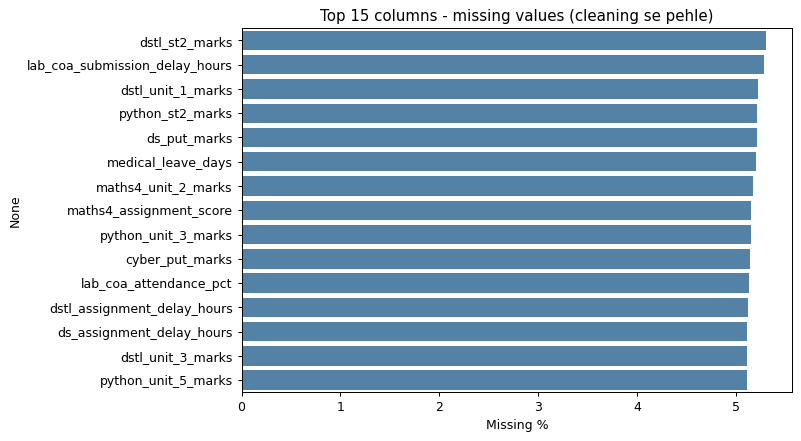

In [21]:
plt.figure(figsize=(9, 5))
top_missing = missing_pct.sort_values(ascending=False).head(15)
sns.barplot(x=top_missing.values, y=top_missing.index, color="steelblue")
plt.xlabel("Missing %")
plt.title("Top 15 columns - missing values (cleaning se pehle)")
plt.tight_layout()
plt.show()

In [22]:
print("Class Sections:")
print(df["class_section"].value_counts(dropna=False))

print("\nSports Activity Levels:")
print(df["sports_activity_level"].value_counts(dropna=False))

Class Sections:
class_section
IT-A     4957
CSE-B    4944
CS-DS    4942
CS-AI    4919
CSE-A    4918
IT-a     4917
CSE-C    4901
IT-B     4891
cse-a    4866
NaN      2245
Name: count, dtype: int64

Sports Activity Levels:
sports_activity_level
moderate    5633
high        5562
N/A         5553
low         5543
LOW         5535
HIGH        5507
None        5462
MODERATE    5457
NaN         2248
Name: count, dtype: int64


## Text columns clean karna

In [23]:
df["class_section"] = df["class_section"].str.upper().str.strip()

df["sports_activity_level"] = df["sports_activity_level"].str.lower().str.strip()

# "n/a" = pata nahi (unknown), "none" = koi sports nahi khelta (alag rakha)
df["sports_activity_level"] = df["sports_activity_level"].replace("n/a", "unknown")

df["full_name"] = df["full_name"].str.strip().str.title()

In [24]:
print("Class Sections:")
print(df["class_section"].value_counts(dropna=False))

print("\nSports Activity Levels:")
print(df["sports_activity_level"].value_counts(dropna=False))

Class Sections:
class_section
IT-A     9874
CSE-A    9784
CSE-B    4944
CS-DS    4942
CS-AI    4919
CSE-C    4901
IT-B     4891
NaN      2245
Name: count, dtype: int64

Sports Activity Levels:
sports_activity_level
moderate    11090
low         11078
high        11069
unknown      5553
none         5462
NaN          2248
Name: count, dtype: int64


In [25]:
df["overall_attendance_pct"].head(20)

0         38
1       70.3
2     53.60%
3       91.1
4       76.4
5       69.9
6       69.4
7        NaN
8       66.9
9     74.00%
10      63.4
11      29.8
12      72.8
13      86.5
14      67.5
15      93.7
16      44.7
17      73.6
18      46.3
19        51
Name: overall_attendance_pct, dtype: str

In [26]:
df["overall_attendance_pct"] = (
    df["overall_attendance_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

df["overall_attendance_pct"] = pd.to_numeric(
    df["overall_attendance_pct"],
    errors="coerce"
)

In [27]:
df["overall_attendance_pct"].dtype

dtype('float64')

## Galat (impossible) values - ye bhi outliers hain

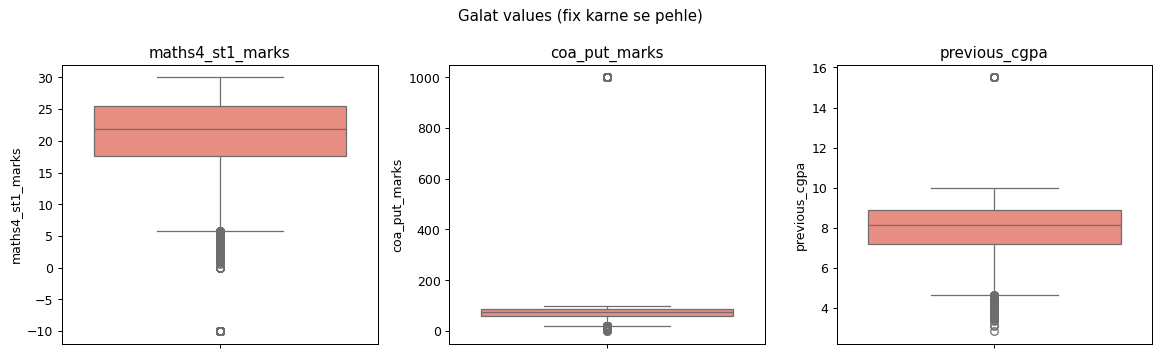

In [28]:
# Pehle plot karke dekhte hain (cleaning se pehle)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.boxplot(y=df["maths4_st1_marks"], ax=axes[0], color="salmon")
axes[0].set_title("maths4_st1_marks")
sns.boxplot(y=df["coa_put_marks"], ax=axes[1], color="salmon")
axes[1].set_title("coa_put_marks")
sns.boxplot(y=df["previous_cgpa"], ax=axes[2], color="salmon")
axes[2].set_title("previous_cgpa")
plt.suptitle("Galat values (fix karne se pehle)")
plt.tight_layout()
plt.show()

In [29]:
print("maths4_st1 negative:", (df["maths4_st1_marks"] < 0).sum())
print("coa_put 100 se upar:", (df["coa_put_marks"] > 100).sum())
print("cgpa 10 se upar:", (df["previous_cgpa"] > 10).sum())

maths4_st1 negative: 150
coa_put 100 se upar: 150
cgpa 10 se upar: 75


In [30]:
# Har column ka valid (min, max). Isse bahar ki value galat hai.
# max = None matlab sirf negative nahi hona chahiye (delay hours, medical leave)
col_rules = {}

for col in number_cols:
    if "_st1_marks" in col or "_st2_marks" in col:
        col_rules[col] = (0, 30)
    elif "_put_marks" in col:
        col_rules[col] = (0, 100)
    elif "_unit_" in col:
        col_rules[col] = (0, 20)
    elif "_assignment_score" in col:
        col_rules[col] = (0, 10)
    elif "_quiz_score" in col:
        col_rules[col] = (0, 10)
    elif "execution_score" in col:
        col_rules[col] = (0, 50)
    elif "viva_score" in col:
        col_rules[col] = (0, 30)
    elif "attendance_pct" in col:
        col_rules[col] = (0, 100)
    elif col in ["previous_cgpa", "final_semester_grade"]:
        col_rules[col] = (0, 10)
    elif col == "society_participation_pc":
        col_rules[col] = (0, 100)
    else:
        col_rules[col] = (0, None)   # delay hours, medical_leave_days

len(col_rules)

95

In [31]:
invalid_report = []

for col in col_rules:
    low = col_rules[col][0]
    high = col_rules[col][1]

    if high is None:
        bad = df[col] < low
    else:
        bad = (df[col] < low) | (df[col] > high)

    if bad.sum() > 0:
        invalid_report.append([col, int(bad.sum()), df.loc[bad, col].min(), df.loc[bad, col].max()])
        df.loc[bad, col] = np.nan      # galat value hata di, aage 0 ho jayegi

invalid_df = pd.DataFrame(invalid_report, columns=["column", "galat_values", "min_galat", "max_galat"])
invalid_df

             column  galat_values  min_galat  max_galat
0     previous_cgpa            75       15.5       15.5
1     coa_put_marks           150      999.0      999.0
2  maths4_st1_marks           150      -10.0      -10.0

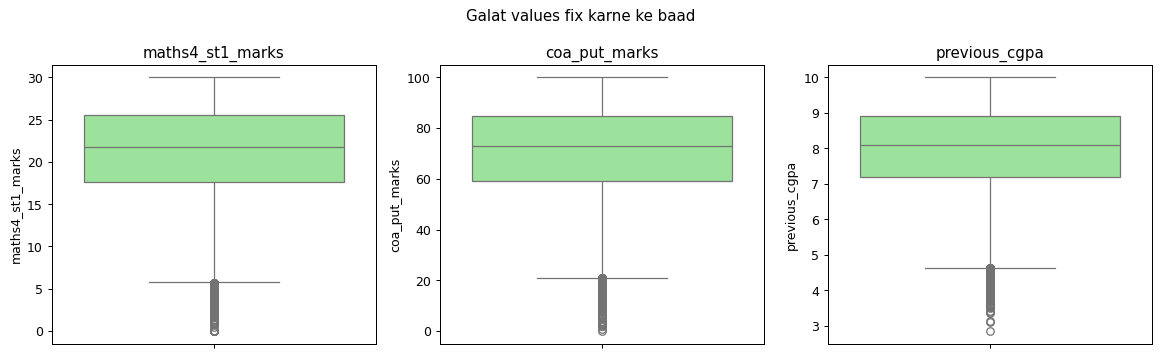

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.boxplot(y=df["maths4_st1_marks"], ax=axes[0], color="lightgreen")
axes[0].set_title("maths4_st1_marks")
sns.boxplot(y=df["coa_put_marks"], ax=axes[1], color="lightgreen")
axes[1].set_title("coa_put_marks")
sns.boxplot(y=df["previous_cgpa"], ax=axes[2], color="lightgreen")
axes[2].set_title("previous_cgpa")
plt.suptitle("Galat values fix karne ke baad")
plt.tight_layout()
plt.show()

## Outlier detection (IQR method)
Q1 = 25% value, Q3 = 75% value, IQR = Q3 - Q1. Jo value `Q1 - 1.5*IQR` se neeche ya `Q3 + 1.5*IQR` se upar ho wo outlier hai. Outliers delete nahi kiye, sirf flag kiye taaki data barbaad na ho. Ye step missing fill se **pehle** hai, warna 0 wali values IQR bigaad dengi.

In [33]:
outlier_report = []
df["outlier_count"] = 0      # har student ke kitne outliers hain

for col in number_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    is_outlier = (df[col] < lower) | (df[col] > upper)

    outlier_report.append([col, round(lower, 2), round(upper, 2), int(is_outlier.sum())])
    df["outlier_count"] = df["outlier_count"] + is_outlier.astype(int)

outlier_df = pd.DataFrame(
    outlier_report,
    columns=["column", "lower_limit", "upper_limit", "outlier_count"]
)
outlier_df = outlier_df.sort_values("outlier_count", ascending=False)
outlier_df.head(10)

                               column  lower_limit  upper_limit  outlier_count
15           society_participation_pc       -27.50        61.30           2076
85      lab_ds_submission_delay_hours        -8.35        46.45           1415
88  lab_python_submission_delay_hours        -8.45        46.35           1406
91     lab_coa_submission_delay_hours        -8.50        46.70           1381
94   lab_cyber_submission_delay_hours        -8.60        46.60           1369
59          ds_assignment_delay_hours       -10.70        58.90           1356
48        dstl_assignment_delay_hours       -10.20        58.60           1323
70      python_assignment_delay_hours       -10.20        58.60           1305
26         coa_assignment_delay_hours       -10.35        58.85           1293
81       cyber_assignment_delay_hours       -10.50        59.10           1289

In [34]:
# jis student ke 5 ya zyada outliers hain use flag kar do
df["is_outlier_student"] = (df["outlier_count"] >= 5).astype(int)

df["is_outlier_student"].sum()

np.int64(1415)

In [35]:
df["outlier_count"].value_counts().sort_index().head(12)

outlier_count
0     32312
1      9859
2      2043
3       595
4       276
5       206
6       165
7       136
8       103
9        77
10       94
11       68
Name: count, dtype: int64

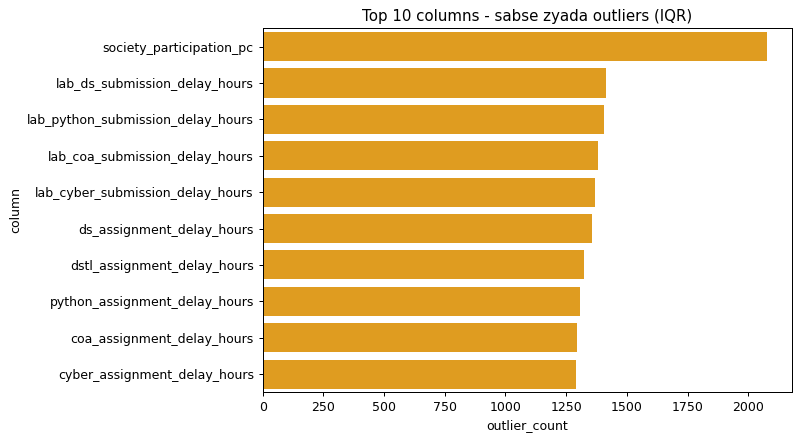

In [36]:
plt.figure(figsize=(9, 5))
top_out = outlier_df.head(10)
sns.barplot(x=top_out["outlier_count"], y=top_out["column"], color="orange")
plt.title("Top 10 columns - sabse zyada outliers (IQR)")
plt.tight_layout()
plt.show()

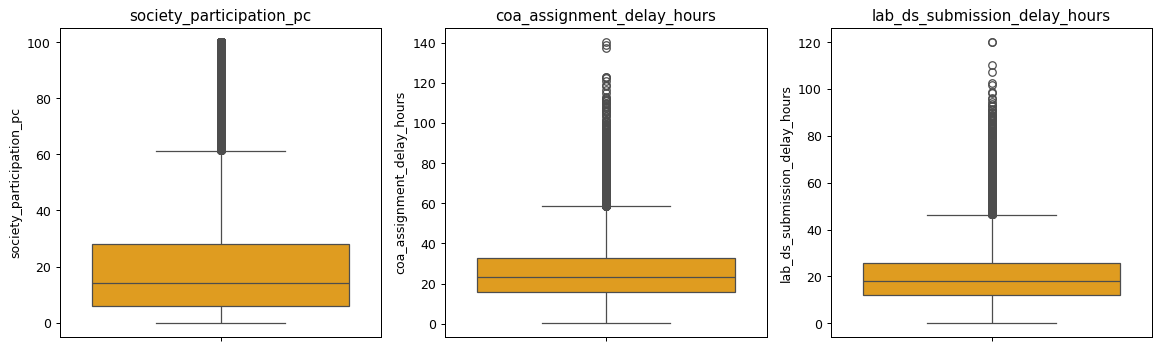

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.boxplot(y=df["society_participation_pc"], ax=axes[0], color="orange")
axes[0].set_title("society_participation_pc")
sns.boxplot(y=df["coa_assignment_delay_hours"], ax=axes[1], color="orange")
axes[1].set_title("coa_assignment_delay_hours")
sns.boxplot(y=df["lab_ds_submission_delay_hours"], ax=axes[2], color="orange")
axes[2].set_title("lab_ds_submission_delay_hours")
plt.tight_layout()
plt.show()

## Missing values - text columns

In [38]:
df[text_cols].isnull().sum()

full_name                2294
class_section            2245
sports_activity_level    2248
dtype: int64

In [39]:
df[df["full_name"].isnull()][["roll_no", "full_name"]].head(10)

          roll_no full_name
8    210029012530       NaN
30   210029047594       NaN
37   210029054208       NaN
43   210029023660       NaN
44   210029016013       NaN
49   210029046974       NaN
58   210029047400       NaN
76   210029012059       NaN
118  210029049011       NaN
131  210029030403       NaN

In [40]:
df["full_name"] = df["full_name"].fillna("Unknown")

In [41]:
df["class_section"] = df["class_section"].fillna("UNKNOWN")

In [42]:
df["sports_activity_level"] = df["sports_activity_level"].fillna("unknown")

In [43]:
df[text_cols].isnull().sum()

full_name                0
class_section            0
sports_activity_level    0
dtype: int64

## Missing values - numeric columns (group-wise, 0 se fill)

In [44]:
df[attendance_cols].isnull().sum()

overall_attendance_pct       2320
theory_attendance_pct        2343
practical_attendance_pct     2289
coa_attendance_pct           2354
maths4_attendance_pct        2330
dstl_attendance_pct          2235
ds_attendance_pct            2306
python_attendance_pct        2309
cyber_attendance_pct         2258
lab_ds_attendance_pct        2288
lab_python_attendance_pct    2356
lab_coa_attendance_pct       2385
lab_cyber_attendance_pct     2338
dtype: int64

In [45]:
df[attendance_cols] = df[attendance_cols].fillna(0)

In [46]:
df[attendance_cols].isnull().sum().sum()

np.int64(0)

In [47]:
df[basic_cols].isnull().sum()

previous_cgpa               2434
medical_leave_days          2419
society_participation_pc    2255
dtype: int64

In [48]:
df[basic_cols] = df[basic_cols].fillna(0)

In [49]:
df[basic_cols].isnull().sum().sum()

np.int64(0)

In [50]:
df[coa_cols].isnull().sum()

coa_st1_marks                 2334
coa_st2_marks                 2297
coa_put_marks                 2463
coa_unit_1_marks              2297
coa_unit_2_marks              2266
coa_unit_3_marks              2322
coa_unit_4_marks              2308
coa_unit_5_marks              2377
coa_assignment_score          2318
coa_assignment_delay_hours    2344
coa_quiz_score                2309
dtype: int64

In [51]:
df[coa_cols] = df[coa_cols].fillna(0)

In [52]:
df[coa_cols].isnull().sum().sum()

np.int64(0)

In [53]:
df[maths4_cols].isnull().sum()

maths4_st1_marks                 2409
maths4_st2_marks                 2343
maths4_put_marks                 2307
maths4_unit_1_marks              2326
maths4_unit_2_marks              2404
maths4_unit_3_marks              2335
maths4_unit_4_marks              2345
maths4_unit_5_marks              2322
maths4_assignment_score          2394
maths4_assignment_delay_hours    2309
maths4_quiz_score                2358
dtype: int64

In [54]:
df[maths4_cols] = df[maths4_cols].fillna(0)

In [55]:
df[maths4_cols].isnull().sum().sum()

np.int64(0)

In [56]:
df[dstl_cols].isnull().sum()

dstl_st1_marks                 2335
dstl_st2_marks                 2463
dstl_put_marks                 2267
dstl_unit_1_marks              2425
dstl_unit_2_marks              2343
dstl_unit_3_marks              2378
dstl_unit_4_marks              2329
dstl_unit_5_marks              2301
dstl_assignment_score          2332
dstl_assignment_delay_hours    2383
dstl_quiz_score                2344
dtype: int64

In [57]:
df[dstl_cols] = df[dstl_cols].fillna(0)

In [58]:
df[dstl_cols].isnull().sum().sum()

np.int64(0)

In [59]:
df[ds_cols].isnull().sum()

ds_st1_marks                 2300
ds_st2_marks                 2222
ds_put_marks                 2421
ds_unit_1_marks              2358
ds_unit_2_marks              2366
ds_unit_3_marks              2285
ds_unit_4_marks              2322
ds_unit_5_marks              2240
ds_assignment_score          2363
ds_assignment_delay_hours    2375
ds_quiz_score                2345
dtype: int64

In [60]:
df[ds_cols] = df[ds_cols].fillna(0)

In [61]:
df[ds_cols].isnull().sum().sum()

np.int64(0)

In [62]:
df[python_cols].isnull().sum()

python_st1_marks                 2358
python_st2_marks                 2423
python_put_marks                 2348
python_unit_1_marks              2269
python_unit_2_marks              2327
python_unit_3_marks              2393
python_unit_4_marks              2329
python_unit_5_marks              2375
python_assignment_score          2335
python_assignment_delay_hours    2226
python_quiz_score                2342
dtype: int64

In [63]:
df[python_cols] = df[python_cols].fillna(0)

In [64]:
df[python_cols].isnull().sum().sum()

np.int64(0)

In [65]:
df[cyber_cols].isnull().sum()

cyber_st1_marks                 2326
cyber_st2_marks                 2237
cyber_put_marks                 2389
cyber_unit_1_marks              2265
cyber_unit_2_marks              2311
cyber_unit_3_marks              2335
cyber_unit_4_marks              2323
cyber_unit_5_marks              2217
cyber_assignment_score          2209
cyber_assignment_delay_hours    2227
cyber_quiz_score                2305
dtype: int64

In [66]:
df[cyber_cols] = df[cyber_cols].fillna(0)

In [67]:
df[cyber_cols].isnull().sum().sum()

np.int64(0)

In [68]:
df[lab_ds_cols].isnull().sum()

lab_ds_execution_score           2353
lab_ds_viva_score                2341
lab_ds_submission_delay_hours    2369
dtype: int64

In [69]:
df[lab_ds_cols] = df[lab_ds_cols].fillna(0)

In [70]:
df[lab_ds_cols].isnull().sum().sum()

np.int64(0)

In [71]:
df[lab_python_cols].isnull().sum()

lab_python_execution_score           2310
lab_python_viva_score                2326
lab_python_submission_delay_hours    2292
dtype: int64

In [72]:
df[lab_python_cols] = df[lab_python_cols].fillna(0)

In [73]:
df[lab_python_cols].isnull().sum().sum()

np.int64(0)

In [74]:
df[lab_coa_cols].isnull().sum()

lab_coa_execution_score           2251
lab_coa_viva_score                2321
lab_coa_submission_delay_hours    2455
dtype: int64

In [75]:
df[lab_coa_cols] = df[lab_coa_cols].fillna(0)

In [76]:
df[lab_coa_cols].isnull().sum().sum()

np.int64(0)

In [77]:
df[lab_cyber_cols].isnull().sum()

lab_cyber_execution_score           2342
lab_cyber_viva_score                2343
lab_cyber_submission_delay_hours    2310
dtype: int64

In [78]:
df[lab_cyber_cols] = df[lab_cyber_cols].fillna(0)

In [79]:
df[lab_cyber_cols].isnull().sum().sum()

np.int64(0)

## final_semester_grade
Isme missing ko seedha 0 karne se student 'fail' jaisa dikhega. Isliye fill karne se pehle ek flag column `grade_was_missing` bana lete hain (1 = grade asal mein missing tha).

In [80]:
df["final_semester_grade"].isnull().sum()

np.int64(2192)

In [81]:
df["grade_was_missing"] = df["final_semester_grade"].isnull().astype(int)

In [82]:
df["grade_was_missing"].sum()

np.int64(2192)

In [83]:
df["final_semester_grade"] = df["final_semester_grade"].fillna(0)

In [84]:
df["final_semester_grade"].isnull().sum()

np.int64(0)

## Final check - saare 99 columns

In [85]:
df.isnull().sum().sum()

np.int64(0)

In [86]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [87]:
df.shape

(46500, 102)

In [88]:
print("99 original columns maujood:", all(c in df.columns for c in all_groups))

99 original columns maujood: True


In [89]:
out_of_range = 0

for col in col_rules:
    low = col_rules[col][0]
    high = col_rules[col][1]

    if high is None:
        out_of_range = out_of_range + int((df[col] < low).sum())
    else:
        out_of_range = out_of_range + int(((df[col] < low) | (df[col] > high)).sum())

print("Range ke bahar values:", out_of_range)

Range ke bahar values: 0


In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df.dtypes.value_counts()

float64    95
int64       4
str         3
Name: count, dtype: int64

In [92]:
print(sorted(df["class_section"].unique()))
print(sorted(df["sports_activity_level"].unique()))

['CS-AI', 'CS-DS', 'CSE-A', 'CSE-B', 'CSE-C', 'IT-A', 'IT-B', 'UNKNOWN']
['high', 'low', 'moderate', 'none', 'unknown']


In [93]:
df.describe()

            roll_no  ...  grade_was_missing
count  4.650000e+04  ...        46500.00000
mean   2.100290e+11  ...            0.04714
std    1.342354e+04  ...            0.21194
min    2.100290e+11  ...            0.00000
25%    2.100290e+11  ...            0.00000
50%    2.100290e+11  ...            0.00000
75%    2.100290e+11  ...            0.00000
max    2.100291e+11  ...            1.00000

[8 rows x 99 columns]

## EDA - cleaning ke baad

In [94]:
df["class_section"].value_counts()

class_section
IT-A       9874
CSE-A      9784
CSE-B      4944
CS-DS      4942
CS-AI      4919
CSE-C      4901
IT-B       4891
UNKNOWN    2245
Name: count, dtype: int64

In [95]:
df["sports_activity_level"].value_counts()

sports_activity_level
moderate    11090
low         11078
high        11069
unknown      7801
none         5462
Name: count, dtype: int64

In [96]:
# grade missing wale students hata ke dekhte hain (warna 0 average bigad dega)
real = df[df["grade_was_missing"] == 0]

real["final_semester_grade"].describe()

count    44308.000000
mean         7.848134
std          1.252994
min          2.870000
25%          7.040000
50%          7.990000
75%          8.800000
max         10.000000
Name: final_semester_grade, dtype: float64

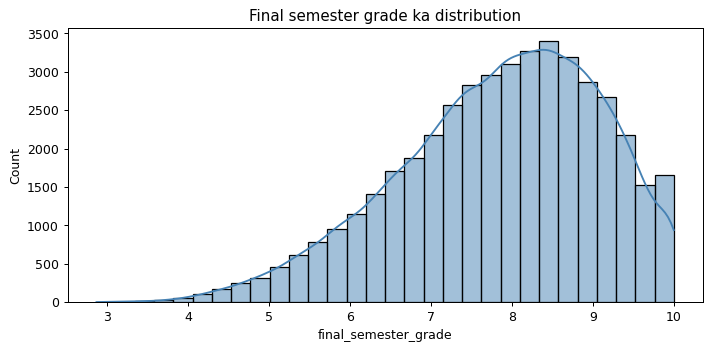

In [97]:
plt.figure(figsize=(8, 4))
sns.histplot(real["final_semester_grade"], bins=30, kde=True, color="steelblue")
plt.title("Final semester grade ka distribution")
plt.tight_layout()
plt.show()

In [98]:
real.groupby("class_section")[["overall_attendance_pct", "previous_cgpa", "final_semester_grade"]].mean().round(2)

               overall_attendance_pct  previous_cgpa  final_semester_grade
class_section                                                             
CS-AI                           67.88           7.58                  7.85
CS-DS                           67.69           7.59                  7.85
CSE-A                           66.96           7.55                  7.83
CSE-B                           67.30           7.58                  7.87
CSE-C                           67.47           7.56                  7.86
IT-A                            67.34           7.56                  7.85
IT-B                            68.10           7.58                  7.87
UNKNOWN                         66.61           7.55                  7.80

In [99]:
real.groupby("sports_activity_level")[["society_participation_pc", "final_semester_grade"]].mean().round(2)

                       society_participation_pc  final_semester_grade
sports_activity_level                                                
high                                      18.67                  7.85
low                                       19.20                  7.85
moderate                                  19.04                  7.85
none                                      19.13                  7.83
unknown                                   19.26                  7.85

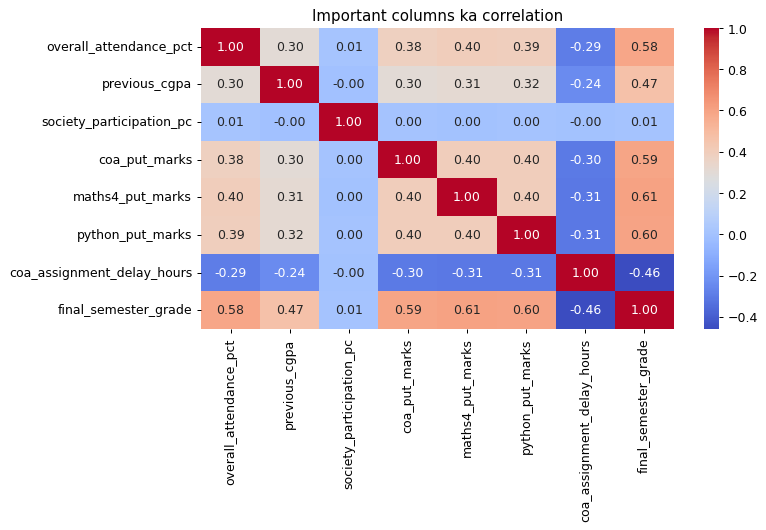

In [100]:
corr_cols = [
    "overall_attendance_pct", "previous_cgpa", "society_participation_pc",
    "coa_put_marks", "maths4_put_marks", "python_put_marks",
    "coa_assignment_delay_hours", "final_semester_grade"
]

plt.figure(figsize=(9, 6))
sns.heatmap(real[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Important columns ka correlation")
plt.tight_layout()
plt.show()

In [101]:
real.corr(numeric_only=True)["final_semester_grade"].drop("final_semester_grade").sort_values(ascending=False).head(8)

dstl_put_marks        0.607084
maths4_put_marks      0.605503
python_put_marks      0.599443
ds_put_marks          0.597572
cyber_st2_marks       0.597354
cyber_put_marks       0.596511
dstl_st1_marks        0.595232
cyber_unit_5_marks    0.595146
Name: final_semester_grade, dtype: float64

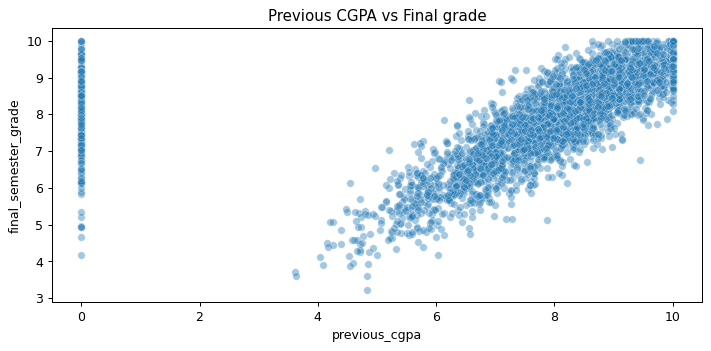

In [102]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=real.sample(3000, random_state=1), x="previous_cgpa", y="final_semester_grade", alpha=0.4)
plt.title("Previous CGPA vs Final grade")
plt.tight_layout()
plt.show()

## Clean data save karna

In [103]:
df.to_csv("edu_growth_cleaned.csv", index=False)

print("Saved! Final shape:", df.shape)

Saved! Final shape: (46500, 102)
